In [ ]:
%matplotlib inline
# tag: remove-cell applied

# Continuous Data with Bayesian Model Averaging

## Table of Contents

- [](#)


Bayesian model averaging is currently available for continuous datasets in `pybmds`using the Bayesian LOUD 
(Leveraging Objective Univariate Distributions) method.  Here, we describe how to run a continuous 
analysis using a single model, or model averaging using the standard BMDS suite of models or the expanded suite
using PROAST or EFSA models.  Additionally, we demonstrate how to plot your results. 

## Single model fit - LOUD

You can run individual models using the Bayesian LOUD approach rather than running all models and finding the model average.

To run the Exponential 5 model: 

   Exponential 5 (CV) Model   
══════════════════════════════

Version: pybmds 25.2a2 (bmdscore 25.2)

Input Summary:
╒══════════════════════════════╤════════════════════════════╕
│ BMR                          │ 1.0 Standard Deviation     │
│ Distribution                 │ Normal + Constant variance │
│ Modeling Direction           │ Up (↑)                     │
│ Confidence Level (one sided) │ 0.95                       │
│ Modeling Approach            │ Bayesian                   │
╘══════════════════════════════╧════════════════════════════╛

Parameter Settings:
╒═════════════╤════════════════╤════════════════════════════════════════════════════════════╕
│ Parameter   │ Distribution   │ Definition                                                 │
╞═════════════╪════════════════╪════════════════════════════════════════════════════════════╡
│ m0          │ Student_t      │ df=19.0, loc=6.0, scale=0.917662935482247                  │
│ m1          │ Student_t      │ df=19.0, loc=30.0,

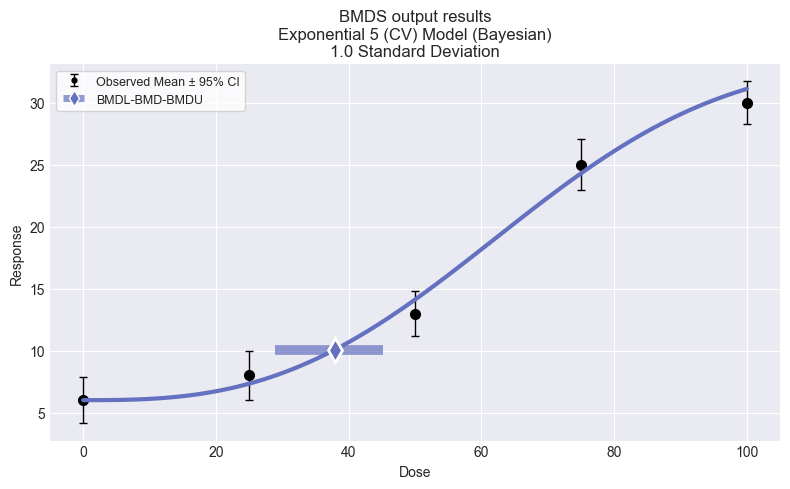

In [2]:
import pybmds
from pybmds.models import continuous

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# Single model fit using LOUD model averaging 
session = pybmds.Session(dataset=dataset)

session.add_model(
pybmds.Models.ExponentialM5,
settings={
    "priors": pybmds.PriorClass.bayesian_loud,
    "disttype":pybmds.ContinuousDistType.normal,
},
)

session.add_model_averaging()
session.execute()

model = session.models[0]

print(model.text())
fig = session.models[0].plot()

## Multiple model fit (sessions) - LOUD

To run LOUD Bayesian model averaging for continuous data using the standard BMDS suite of models:

BMD = 37.69 [28.09, 45.08]


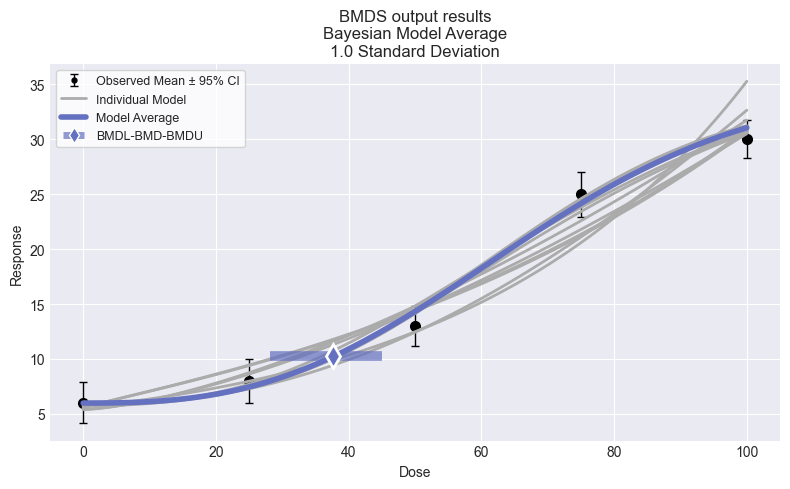

In [8]:
import pybmds

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# LOUD model averaging using the standard BMDS continuous suite
session1 = pybmds.Session(dataset=dataset)
session1.add_default_bayesian_models(
    prior_class=pybmds.PriorClass.bayesian_loud,
    model_average=True,      # add model averaging
    include_extended=False,  # standard suite only (not PROAST/EFSA-expanded)
)
session1.execute()

# summarize model-averaged result
res1 = session1.model_average.results
print(f"BMD = {res1.bmd:.2f} [{res1.bmdl:.2f}, {res1.bmdu:.2f}]")

# optional: plot model fits and model-average curve
fig1 = session1.plot(colorize=False)

To display a summary table of results:

In [9]:
import numpy as np
import pandas as pd

def summary_table_loud_ma(session):
    if session.model_average is None:
        raise ValueError("This function expects a model-average session (session.model_average is None).")

    res1 = session.model_average.results
    alpha = session.models[0].settings.alpha

    rows = []
    for i, model in enumerate(session.models):
        ms = res1.model_summary(i, alpha=alpha)  # per-model BMDL/BMD/BMDU from MA draws
        roi = np.nan
        if model.results is not None and getattr(model.results, "gof", None) is not None:
            roi = getattr(model.results.gof, "roi", np.nan)  # scaled residual (residual of interest)

        rows.append({
            "Model": model.name(),
            "Model Weight": float(res.posteriors[i]),
            "BMDL": float(ms.bmdl),
            "BMD": float(ms.bmd),
            "BMDU": float(ms.bmdu),
            "Scaled Residual": float(roi),
        })

    return pd.DataFrame(rows)

summary_table_loud_ma(session1)

,Model,Model Weight,BMDL,BMD,BMDU,Scaled Residual
0,Power (CV),0.005547,23.494860,30.057729,37.290974,-0.720260
1,Power (NCV),0.006145,22.587561,29.865614,37.741317,-0.724404
2,Hill (CV),0.165873,28.334663,37.180560,44.444769,0.480381
3,Hill (NCV),0.094513,27.082097,36.811919,45.085158,0.403957
4,Exponential 3 (CV),0.000110,20.629910,27.844691,36.143974,-1.479982
5,Exponential 3 (NCV),0.000158,19.246586,27.398044,36.585955,-1.457518
6,Exponential 3 (Lognormal),0.000299,20.058322,28.648899,38.634770,-0.792131
7,Exponential 5 (CV),0.419887,28.856224,37.933179,45.146264,-1.418461
8,Exponential 5 (NCV),0.301912,28.017142,38.103377,45.518864,-1.443800
9,Exponential 5 (Lognormal),0.005556,24.158342,32.169295,41.080501,0.247202


To run LOUD Bayesian model averaging for continuous data using the expanded suite of models (i.e., BMDS + PROAST + EFSA models):

BMD = 43.06 [31.92, 48.48]


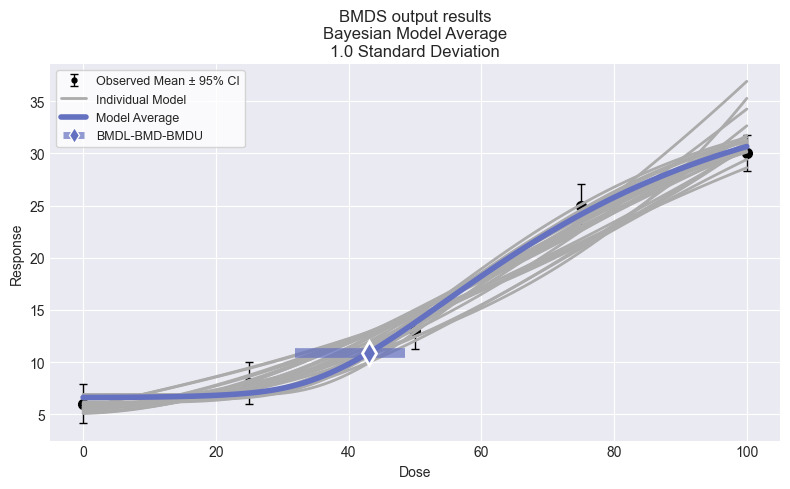

In [10]:
import pybmds

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# LOUD model averaging using the standard BMDS continuous suite
session2 = pybmds.Session(dataset=dataset)
session2.add_default_bayesian_models(
    prior_class=pybmds.PriorClass.bayesian_loud,
    model_average=True,      # add model averaging
    include_extended=True,  # standard suite only (not PROAST/EFSA-expanded)
)
session2.execute()

# summarize model-averaged result
res2 = session2.model_average.results
print(f"BMD = {res2.bmd:.2f} [{res2.bmdl:.2f}, {res2.bmdu:.2f}]")

# optional: plot model fits and model-average curve
fig2 = session2.plot(colorize=False)

And to print out a summary table:

In [11]:
import numpy as np
import pandas as pd

def summary_table_loud_ma(session):
    if session.model_average is None:
        raise ValueError("This function expects a model-average session (session.model_average is None).")

    res2 = session.model_average.results
    alpha = session.models[0].settings.alpha

    rows = []
    for i, model in enumerate(session.models):
        ms = res2.model_summary(i, alpha=alpha)  # per-model BMDL/BMD/BMDU from MA draws
        roi = np.nan
        if model.results is not None and getattr(model.results, "gof", None) is not None:
            roi = getattr(model.results.gof, "roi", np.nan)  # scaled residual (residual of interest)

        rows.append({
            "Model": model.name(),
            "Model Weight": float(res2.posteriors[i]),
            "BMDL": float(ms.bmdl),
            "BMD": float(ms.bmd),
            "BMDU": float(ms.bmdu),
            "Scaled Residual": float(roi),
        })

    return pd.DataFrame(rows)

summary_table_loud_ma(session2)

,Model,Model Weight,BMDL,BMD,BMDU,Scaled Residual
0,Power (CV),0.000787,23.494860,30.057729,37.290974,-0.720260
1,Power (NCV),0.000872,22.587561,29.865614,37.741317,-0.724404
2,Exponential 3 (CV),0.000016,20.629910,27.844691,36.143974,-1.479982
3,Exponential 3 (NCV),0.000022,19.246586,27.398044,36.585955,-1.457518
4,Exponential 3 (Lognormal),0.000042,20.058322,28.648899,38.634770,-0.792131
5,Exponential 5 (CV),0.059554,28.856224,37.933179,45.146264,-1.418461
6,Exponential 5 (NCV),0.042821,28.017142,38.103377,45.518864,-1.443800
7,Exponential 5 (Lognormal),0.000788,24.158342,32.169295,41.080501,0.247202
8,Multiplicative Hill (CV),0.023526,28.334663,37.180560,44.444769,0.486898
9,Multiplicative Hill (NCV),0.013405,27.082097,36.811919,45.085158,0.413433


To run LOUD Bayesian model averaging for continuous data using the just the PROAST and EFSA models:

BMD = 43.08 [31.91, 48.50]


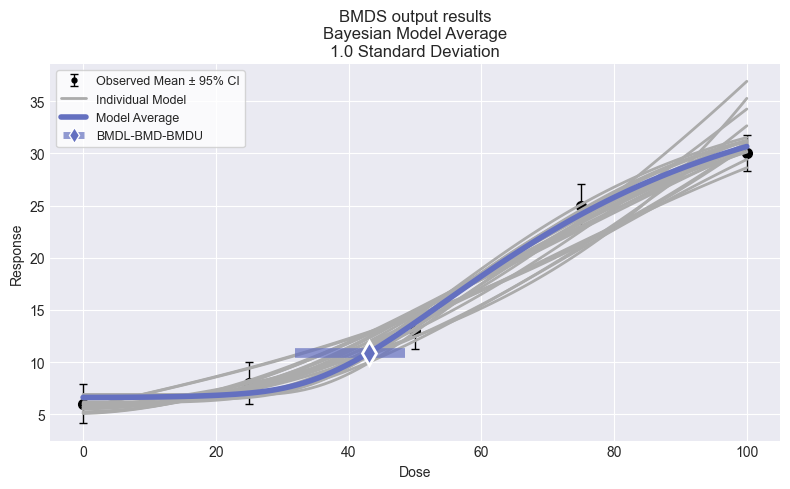

In [13]:
# dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

session3 = pybmds.Session(dataset=dataset)

# Expanded models only (PROAST/EFSA-style set), LOUD priors
expanded_models = [
    pybmds.Models.ExponentialM3,
    pybmds.Models.ExponentialM5,
    pybmds.Models.MultiplicativeHill,
    pybmds.Models.InverseExponential,
    pybmds.Models.Lognormal,
    pybmds.Models.ContinuousGamma,
    pybmds.Models.LMS2,
]

# add all three disttypes (example: constant variance)
dist_types = [
    pybmds.ContinuousDistType.normal,
    pybmds.ContinuousDistType.normal_ncv,
    pybmds.ContinuousDistType.log_normal,
]

for model_name in expanded_models:
    for dt in dist_types:
        session3.add_model(
            model_name,
            settings={
                "priors": pybmds.PriorClass.bayesian_loud,
                "disttype": dt,
            },
        )

session3.add_model_averaging()
session3.execute()

res3 = session3.model_average.results
print(f"BMD = {res3.bmd:.2f} [{res3.bmdl:.2f}, {res3.bmdu:.2f}]")
fig3 = session3.plot(colorize=False)

To print a summary table for the EFSA and PROAST models:

In [14]:
summary_table_loud_ma(session3)

,Model,Model Weight,BMDL,BMD,BMDU,Scaled Residual
0,Exponential 3 (CV),0.000016,20.629910,27.844691,36.143974,-1.479982
1,Exponential 3 (NCV),0.000022,19.246586,27.398044,36.585955,-1.457518
2,Exponential 3 (Lognormal),0.000042,20.058322,28.648899,38.634770,-0.792131
3,Exponential 5 (CV),0.059653,28.856224,37.933179,45.146264,-1.418461
4,Exponential 5 (NCV),0.042892,28.017142,38.103377,45.518864,-1.443800
5,Exponential 5 (Lognormal),0.000789,24.158342,32.169295,41.080501,0.247202
6,Multiplicative Hill (CV),0.023565,28.334663,37.180560,44.444769,0.486898
7,Multiplicative Hill (NCV),0.013427,27.082097,36.811919,45.085158,0.413433
8,Multiplicative Hill (Lognormal),0.000923,23.259407,31.117116,39.292956,0.220687
9,Inverse Exponential (CV),0.296165,38.006134,44.411933,48.792456,-0.506609


To compare the model averaged results for all three analyses using different model suites:

In [15]:
import pandas as pd

def ma_point_summary(session, label):
    if session.model_average is None:
        raise ValueError(f"{label} has no model average.")
    r = session.model_average.results
    return {
        "Session": label,
        "BMDL": float(r.bmdl),
        "BMD": float(r.bmd),
        "BMDU": float(r.bmdu),
    }

comparison = pd.DataFrame([
    ma_point_summary(session1, "Session 1 (BMDS only)"),
    ma_point_summary(session2, "Session 2 (BMDS + Expanded)"),
    ma_point_summary(session3, "Session 3 (Expanded only)"),
])

comparison

,Session,BMDL,BMD,BMDU
0,Session 1 (BMDS only),28.086155,37.694524,45.079079
1,Session 2 (BMDS + Expanded),31.918987,43.055159,48.482431
2,Session 3 (Expanded only),31.905711,43.083468,48.499404
